In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DRIVE_BASE       = Path("/content/drive/My Drive/CS_510/")
SENTIMENT_PATH   = DRIVE_BASE / "sentiment_by_product.json"
OUT_PATH         = DRIVE_BASE / "regression_scores.json"

SKIP_PRODUCTS    = {
    "Neutrogena Hydro Boost Water Gel",
    "Apple Watch Series 11",
}
MIN_PLATFORM_REVIEWS = 10  

print(f"sentiment_by_product exists: {SENTIMENT_PATH.exists()}")

sentiment_by_product exists: True


In [ ]:
with open(SENTIMENT_PATH, encoding="utf-8") as f:
    by_product = json.load(f)

rows = []

for product_name, entry in by_product.items():
    if product_name in SKIP_PRODUCTS:
        continue
    if entry["rated_reviews"] < 20:
        continue

    # ── Aggregate per source ─────────────────────────────────────────────────
    sources = defaultdict(lambda: {"pos": 0, "neu": 0, "neg": 0, "ratings": [], "total": 0})

    for r in entry["reviews"]:
        src = r.get("source", "")
        if not src or r.get("sentiment") == "unrated":
            continue
        sources[src]["total"] += 1
        s = r.get("sentiment")
        if s == "positive":  sources[src]["pos"] += 1
        elif s == "neutral": sources[src]["neu"] += 1
        elif s == "negative":sources[src]["neg"] += 1
        if r.get("rating") is not None:
            sources[src]["ratings"].append(float(r["rating"]))

    for src, c in sources.items():
        t = c["total"]
        if t < MIN_PLATFORM_REVIEWS:
            continue

        pos_pct = round(c["pos"] / t * 100, 2)
        neu_pct = round(c["neu"] / t * 100, 2)
        neg_pct = round(c["neg"] / t * 100, 2)
        avg_rating = round(sum(c["ratings"]) / len(c["ratings"]), 3) if c["ratings"] else None

        confidence = min(1.0, t / 50)
        raw        = (c["pos"] + 0.5 * c["neu"]) / t
        trust      = round((raw * confidence + 0.5 * (1 - confidence)) * 100, 2)

        rows.append({
            "product_name":  product_name,
            "source":        src,
            "review_count":  t,
            "avg_rating":    avg_rating if avg_rating is not None else 3.0,
            "positive_pct":  pos_pct,
            "neutral_pct":   neu_pct,
            "negative_pct":  neg_pct,
            "trust_score":   trust,
        })

df = pd.DataFrame(rows)
print(f"Feature matrix: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Products: {df['product_name'].nunique()} | Platforms: {df['source'].nunique()}")
df

Feature matrix: 28 rows × 8 columns
Products: 10 | Platforms: 3


,product_name,source,review_count,avg_rating,positive_pct,neutral_pct,negative_pct,trust_score
0,OxiClean White Revive Laundry Whitener,amazon_txt,100,4.350,82.00,5.00,13.00,84.50
1,OxiClean White Revive Laundry Whitener,target_txt,304,4.046,75.33,8.88,15.79,79.77
2,OxiClean White Revive Laundry Whitener,walmart_txt,100,4.690,91.00,2.00,7.00,92.00
3,Dyson V8 Cordless Vacuum,target_txt,304,3.007,45.07,13.16,41.78,51.64
4,Dyson V8 Cordless Vacuum,walmart_txt,100,3.600,60.00,11.00,29.00,65.50
5,Crocs,amazon_txt,100,4.560,89.00,4.00,7.00,91.00
6,Crocs,target_txt,302,4.238,80.79,3.97,15.23,82.78
7,Crocs,walmart_txt,100,3.880,73.00,0.00,27.00,73.00
8,Apple Airpods 4,amazon_txt,100,3.670,63.00,7.00,30.00,66.50
9,Apple Airpods 4,target_txt,304,3.033,45.07,8.55,46.38,49.34


In [ ]:
df["log_review_count"] = np.log1p(df["review_count"])

df["pos_neg_gap"] = df["positive_pct"] - df["negative_pct"]

platform_dummies = pd.get_dummies(df["source"], prefix="platform")
df_features = pd.concat([df, platform_dummies], axis=1)

FEATURE_COLS = (
    ["positive_pct", "neutral_pct", "negative_pct",
     "avg_rating", "log_review_count", "pos_neg_gap"]
    + list(platform_dummies.columns)
)
TARGET_COL = "trust_score"

X = df_features[FEATURE_COLS].values.astype(float)
y = df_features[TARGET_COL].values.astype(float)

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"X shape: {X.shape} | y range: [{y.min():.1f}, {y.max():.1f}]")

Features (9): ['positive_pct', 'neutral_pct', 'negative_pct', 'avg_rating', 'log_review_count', 'pos_neg_gap', 'platform_amazon_txt', 'platform_target_txt', 'platform_walmart_txt']
X shape: (28, 9) | y range: [19.0, 95.5]


In [ ]:
loo = LeaveOneOut()

elasticnet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-3, 1, 50),
        cv=loo,
        max_iter=10000,
        random_state=42,
    ))
])

elasticnet_pipe.fit(X, y)

en_model    = elasticnet_pipe.named_steps["model"]
best_alpha  = en_model.alpha_
best_l1     = en_model.l1_ratio_

print(f"Best alpha    : {best_alpha:.4f}")
print(f"Best l1_ratio : {best_l1:.2f}")
loo_preds_en = cross_val_predict(elasticnet_pipe, X, y, cv=loo)

mae_en  = mean_absolute_error(y, loo_preds_en)
rmse_en = np.sqrt(mean_squared_error(y, loo_preds_en))
r2_en   = r2_score(y, loo_preds_en)

print(f"\nElasticNet LOO performance:")
print(f"  MAE  : {mae_en:.2f}")
print(f"  RMSE : {rmse_en:.2f}")
print(f"  R²   : {r2_en:.3f}")

ElasticNet feature weights (non-zero only):
     feature    weight  abs_weight
positive_pct 20.407389   20.407389
 neutral_pct  1.468369    1.468369
negative_pct -0.329245    0.329245


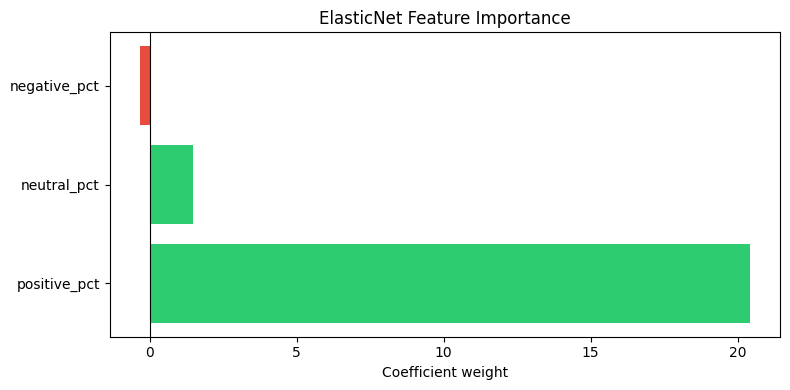

In [11]:
scaler  = elasticnet_pipe.named_steps["scaler"]
en_coef = elasticnet_pipe.named_steps["model"].coef_

importance_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "weight": en_coef})
    .assign(abs_weight=lambda d: d["weight"].abs())
    .sort_values("abs_weight", ascending=False)
    .reset_index(drop=True)
)

print("ElasticNet feature weights (non-zero only):")
print(importance_df[importance_df["abs_weight"] > 0].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
nonzero = importance_df[importance_df["abs_weight"] > 0]
colors  = ["#2ecc71" if w >= 0 else "#e74c3c" for w in nonzero["weight"]]
ax.barh(nonzero["feature"], nonzero["weight"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient weight")
ax.set_title("ElasticNet Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestRegressor(
        n_estimators=200,
        max_depth=3,          
        min_samples_leaf=2,
        random_state=42,
    ))
])

loo_preds_rf = cross_val_predict(rf_pipe, X, y, cv=loo)

mae_rf  = mean_absolute_error(y, loo_preds_rf)
rmse_rf = mean_squared_error(y, loo_preds_rf) ** 0.5
r2_rf   = r2_score(y, loo_preds_rf)

print(f"RandomForest LOO performance:")
print(f"  MAE  : {mae_rf:.2f}")
print(f"  RMSE : {rmse_rf:.2f}")
print(f"  R²   : {r2_rf:.3f}")

rf_pipe.fit(X, y)
rf_importance = (
    pd.DataFrame({"feature": FEATURE_COLS,
                  "weight":  rf_pipe.named_steps["model"].feature_importances_})
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)
print("\nRF feature importances:")
print(rf_importance[rf_importance["weight"] > 0.01].to_string(index=False))

RandomForest LOO performance:
  MAE  : 2.40
  RMSE : 4.60
  R²   : 0.950

RF feature importances:
     feature   weight
positive_pct 0.283609
negative_pct 0.270351
  avg_rating 0.238710
 pos_neg_gap 0.203107


       Model  MAE  RMSE   R²
  ElasticNet  0.0   0.0 1.00
RandomForest  2.4   4.6 0.95

Selected model: ElasticNet


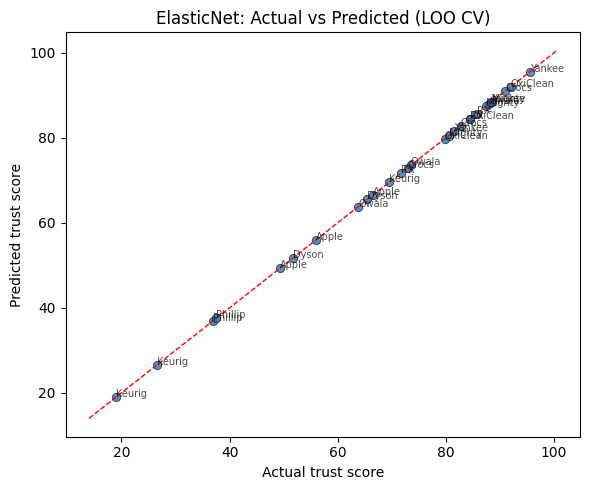

In [ ]:
comparison = pd.DataFrame({
    "Model":  ["ElasticNet", "RandomForest"],
    "MAE":    [round(mae_en, 2),  round(mae_rf, 2)],
    "RMSE":   [round(rmse_en, 2), round(rmse_rf, 2)],
    "R²":     [round(r2_en, 3),   round(r2_rf, 3)],
})
print(comparison.to_string(index=False))

best_model_name = "ElasticNet" if mae_en <= mae_rf else "RandomForest"
best_pipe       = elasticnet_pipe if best_model_name == "ElasticNet" else rf_pipe
best_preds      = loo_preds_en    if best_model_name == "ElasticNet" else loo_preds_rf
best_importance = importance_df   if best_model_name == "ElasticNet" else rf_importance
print(f"\nSelected model: {best_model_name}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y, best_preds, alpha=0.8, edgecolors="k", linewidths=0.5)
lims = [min(y.min(), best_preds.min()) - 5, max(y.max(), best_preds.max()) + 5]
ax.plot(lims, lims, "r--", linewidth=1)
for i, row in df.iterrows():
    ax.annotate(row["product_name"].split()[0], (y[i], best_preds[i]),
                fontsize=7, alpha=0.7)
ax.set_xlabel("Actual trust score")
ax.set_ylabel("Predicted trust score")
ax.set_title(f"{best_model_name}: Actual vs Predicted (LOO CV)")
plt.tight_layout()
plt.show()

In [ ]:
def compute_confidence(product_rows: pd.DataFrame) -> float:
    
    total_reviews  = product_rows["review_count"].sum()
    volume_factor  = min(1.0, np.log1p(total_reviews) / np.log1p(1000))

    if len(product_rows) > 1:
        platform_trusts  = product_rows["trust_score"].values
        trust_std        = np.std(platform_trusts)
        agreement_factor = max(0.0, 1.0 - trust_std / 50)
    else:
        agreement_factor = 0.6   

    platform_factor = min(1.0, 0.6 + 0.2 * len(product_rows))

    confidence = round(volume_factor * 0.4 + agreement_factor * 0.4 + platform_factor * 0.2, 2)
    return confidence



for product, grp in df.groupby("product_name"):
    conf = compute_confidence(grp)
    print(f"  {product:<50} confidence={conf}")

  Apple Airpods 4                                    confidence=0.9
  Crocs                                              confidence=0.9
  Dyson V8 Cordless Vacuum                           confidence=0.89
  Keurig K-Mini Single Serve Coffee Maker            confidence=0.78
  Mighty Patch Original (Hero Cosmetics)             confidence=0.93
  Owala Water Bottle                                 confidence=0.88
  OxiClean White Revive Laundry Whitener             confidence=0.92
  Phillip Sonicare 4100 Series Electric Toothbrush   confidence=0.95
  RX Bar Vanilla Almond Protein Bars                 confidence=0.89
  Yankee Candle Lemon Lavender Scented Candle        confidence=0.91


In [ ]:
def slugify(name: str) -> str:
    import re
    s = name.lower()
    s = re.sub(r'[^a-z0-9\s-]', '', s)
    s = re.sub(r'[\s-]+', '-', s).strip('-')
    return s


best_pipe.fit(X, y)
df_features["predicted_trust"] = best_pipe.predict(X).round(1)

regression_scores = []

for product_name, grp in df_features.groupby("product_name"):
    product_rows = grp.reset_index(drop=True)

    weights       = product_rows["review_count"].values
    predicted_trusts = product_rows["predicted_trust"].values
    overall_trust = int(round(np.average(predicted_trusts, weights=weights)))
    confidence    = compute_confidence(product_rows)

    feat_imp = [
        {"feature": row["feature"], "weight": round(float(row["weight"]), 4)}
        for _, row in best_importance.iterrows()
        if abs(row["weight"]) > 0.01
    ][:6]   # top 6 only

    platform_trends = []
    for _, row in product_rows.iterrows():
        platform_trends.append({
            "source":          row["source"],
            "review_count":    int(row["review_count"]),
            "avg_rating":      round(float(row["avg_rating"]), 2),
            "positive_pct":    int(row["positive_pct"]),
            "neutral_pct":     int(row["neutral_pct"]),
            "negative_pct":    int(row["negative_pct"]),
            "predicted_trust": int(round(float(row["predicted_trust"]))),
        })

    regression_scores.append({
        "product_id":        slugify(product_name),
        "product_name":      product_name,
        "model":             best_model_name,
        "trust_score":       overall_trust,
        "confidence":        confidence,
        "platform_trends":   platform_trends,
        "feature_importance": feat_imp,
    })

regression_scores.sort(key=lambda x: x["trust_score"], reverse=True)

with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(regression_scores, f, indent=2, ensure_ascii=False)

print(f"Saved -> {OUT_PATH}")
print(f"Scored products: {len(regression_scores)}\n")
for p in regression_scores:
    print(f"  [{p['trust_score']:>3}] conf={p['confidence']}  {p['product_name']}")

Saved -> /content/drive/My Drive/CS_510/regression_scores.json
Scored products: 10

  [ 88] conf=0.91  Yankee Candle Lemon Lavender Scented Candle
  [ 87] conf=0.93  Mighty Patch Original (Hero Cosmetics)
  [ 83] conf=0.92  OxiClean White Revive Laundry Whitener
  [ 82] conf=0.9  Crocs
  [ 81] conf=0.89  RX Bar Vanilla Almond Protein Bars
  [ 71] conf=0.88  Owala Water Bottle
  [ 55] conf=0.89  Dyson V8 Cordless Vacuum
  [ 54] conf=0.9  Apple Airpods 4
  [ 37] conf=0.95  Phillip Sonicare 4100 Series Electric Toothbrush
  [ 34] conf=0.78  Keurig K-Mini Single Serve Coffee Maker


In [ ]:
sample = next(p for p in regression_scores if "owala" in p["product_id"].lower())
print(json.dumps(sample, indent=2))

{
  "product_id": "owala-water-bottle",
  "product_name": "Owala Water Bottle",
  "model": "ElasticNet",
  "trust_score": 71,
  "confidence": 0.88,
  "platform_trends": [
    {
      "source": "amazon_txt",
      "review_count": 100,
      "avg_rating": 3.95,
      "positive_pct": 68,
      "neutral_pct": 11,
      "negative_pct": 21,
      "predicted_trust": 74
    },
    {
      "source": "target_txt",
      "review_count": 304,
      "avg_rating": 3.53,
      "positive_pct": 60,
      "neutral_pct": 6,
      "negative_pct": 32,
      "predicted_trust": 64
    },
    {
      "source": "walmart_txt",
      "review_count": 100,
      "avg_rating": 4.49,
      "positive_pct": 86,
      "neutral_pct": 4,
      "negative_pct": 10,
      "predicted_trust": 88
    }
  ],
  "feature_importance": [
    {
      "feature": "positive_pct",
      "weight": 20.4074
    },
    {
      "feature": "neutral_pct",
      "weight": 1.4684
    },
    {
      "feature": "negative_pct",
      "weight": -0.3